# DeltaNet：用 delta rule 给线性注意力装上"橡皮擦"

线性注意力把历史压进一个固定大小的**状态矩阵** $S\in\mathbb R^{K\times V}$，每步更新、读出 $o_t=S_t^\top q_t$。
最朴素的更新 $S_t=S_{t-1}+k_tv_t^\top$ **只加不减**：写入新记忆从不擦旧的，键冲突时旧值残留、互相干扰。

**DeltaNet** 借在线学习的 *delta 规则*（Widrow–Hoff / 快速权重）给它装上"橡皮擦"：写入前先用 $k_t$ 查询旧状态、
算预测误差，只写入**误差**——等价于先擦掉 $k_t$ 方向的旧记忆、再写新值。这一章把它的几何与 chunk 并行一步步推清楚：

1. §1 先**亲眼看见**朴素线性注意力的键冲突；
2. §2 把 **delta rule 的几何**讲透——为什么 $(I-\beta_t k_tk_t^\top)$ 是"沿 $k_t$ 方向的擦除"（后续 KDA/GDN 都引用这里）；
3. §3 推导 **WY 表示**——把块内串行擦除解成一次三角求逆，这是 chunk 并行 kernel 的地基，DeltaNet 无门控，是最干净的原型；
4. §4 **逐段精读**可读的 chunk 实现；
5. §5 保留**完整 kernel 源码**并验证本仓库解耦自 fla 的实现与原版一致。

In [1]:
import sys, math
from pathlib import Path

import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CH = ROOT / "11-deltanet"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(CH))

from common.nbtools import setup_cjk, show_code
setup_cjk()                                       # 中文字体 + retina 高清出图
from deltanet import delta_rule_recurrent, delta_rule_chunked   # 简要版：recurrent + WY chunk

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))

跑在 NVIDIA GeForce RTX 4090


## 1. 先亲眼看见：朴素线性注意力无法"覆盖更新"

朴素线性注意力把每对 $(k_i,v_i)$ 直接累加进状态：$S=\sum_i k_iv_i^\top$。如果同一个 key $k$ 先写入 $v_a$、之后想**覆盖**
成 $v_b$，它只会把两者**累加**，无法覆盖：

$$S^\top k=(k^\top k)\,(v_a+v_b)=v_a+v_b\;\neq\;v_b.$$

**delta rule** 在写 $v_b$ 前，先用 $k$ 读出旧值 $\hat v=S^\top k=v_a$、算误差 $v_b-v_a$、**只写误差**，于是状态精确变成
$S=k\,v_b^\top$，读出就是 $v_b$——成功覆盖。下面对比。

In [2]:
# 同一个 key，先写 v_a、再想覆盖成 v_b
k = F.normalize(torch.tensor([1.0, 0.5, -0.3]), dim=0)            # 一个 key（已归一化）
v_a = torch.tensor([1.0, 0.0, 0.0]); v_b = torch.tensor([0.0, 1.0, 0.0])

S_lin = torch.outer(k, v_a) + torch.outer(k, v_b)                # 朴素 linear：两次写入直接累加
print(f"朴素 linear  读出: {[round(x,2) for x in (S_lin.T @ k).tolist()]}   → v_a+v_b 累加，覆盖失败")

# DeltaNet：同一个 key 写 v_a 再写 v_b（先擦后写）
q = k.reshape(1, 1, 1, 3).repeat(1, 1, 2, 1).cuda()             # 两步都用 k 读（看第 2 步）
kk = k.reshape(1, 1, 1, 3).repeat(1, 1, 2, 1).cuda()
vv = torch.stack([v_a, v_b]).reshape(1, 1, 2, 3).cuda()
beta = torch.ones(1, 1, 2).cuda()
o = delta_rule_recurrent(q, kk, vv, beta, l2norm=True, scale=1.0)
print(f"DeltaNet     读出: {[round(x,2) for x in o[0,0,1].tolist()]}   → ≈ v_b，成功覆盖（先擦 v_a 再写 v_b）")

朴素 linear  读出: [1.0, 1.0, 0.0]   → v_a+v_b 累加，覆盖失败
DeltaNet     读出: [0.0, 1.0, 0.0]   → ≈ v_b，成功覆盖（先擦 v_a 再写 v_b）


## 2. delta rule：先擦后写（几何讲透）

DeltaNet 把状态 $S$ 看成一个线性映射 $k\mapsto v$，每来一对 $(k_t,v_t)$ 就像做一步在线学习的修正，分三步：

$$
\underbrace{\hat v_t=S_{t-1}^\top k_t}_{\text{① 读出 }k_t\text{ 方向的旧值}}\qquad
\underbrace{\Delta_t=\beta_t\,(v_t-\hat v_t)}_{\text{② 算预测误差}}\qquad
\underbrace{S_t=S_{t-1}+k_t\,\Delta_t^\top}_{\text{③ 沿 }k_t\text{ 写回修正}}
$$

把 $\hat v_t=S_{t-1}^\top k_t$ 代回 ③ 合并，得到 DeltaNet 的状态更新式（关键代数变形）：

$$
S_t=S_{t-1}+\beta_t\,k_t\bigl(v_t-S_{t-1}^\top k_t\bigr)^\top
   =\boxed{(I-\beta_t\,k_tk_t^\top)\,S_{t-1}+\beta_t\,k_tv_t^\top}.
$$

**几何**：当 $\lVert k_t\rVert=1,\beta_t=1$ 时，$I-k_tk_t^\top$ 正是把向量在 $k_t$ 方向分量**清零**的正交投影（保留垂直分量）。
所以 delta rule = **写入 $k_t$ 前，先把状态里 $k_t$ 方向已存的旧内容擦掉**，再写新的 $v_t$；$\beta_t\in[0,1]$ 是擦/写的力度
（像学习率）。这正是 §1 里"覆盖更新"能成功的原因，也缓解了非正交 key 的串扰。下面把"擦除"画出来。

> 这条几何是后面所有 gated delta（**第 12 章 KDA**、**第 13 章 GDN/GDN-2**）的共同基础——它们都在这个擦除算子上
> 再叠门控、或把 erase/write 拆成两个门。

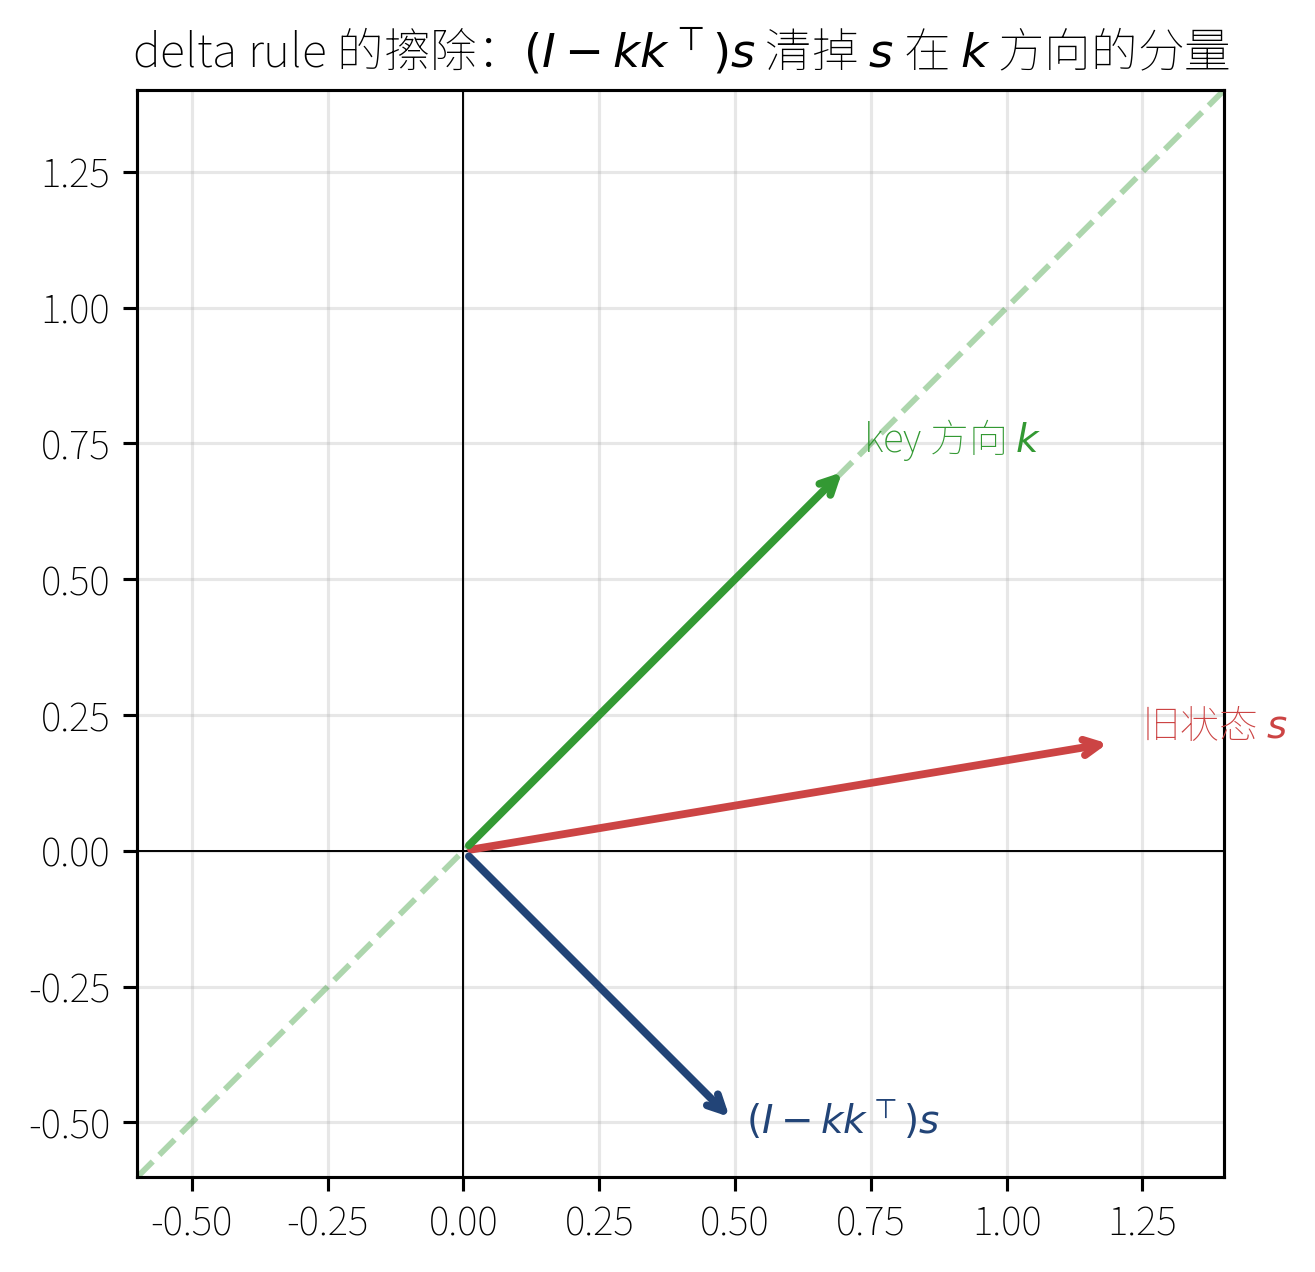

擦除后向量与 k 正交：s_erased · k = 2.98e-08
→ 写入新 v 前先沿 k 擦掉旧值——这就是 delta rule 实现覆盖更新的几何本质。


In [3]:
# 2D 演示：状态在 k 方向有旧分量，(I - k k^T) 把它沿 k 擦掉，只留垂直分量
k_dir = torch.tensor([1.0, 1.0]); k_dir = k_dir / k_dir.norm()
s_old = torch.tensor([1.2, 0.2])
P = torch.eye(2) - torch.outer(k_dir, k_dir)                      # 擦除算子 I - k k^T
s_erased = P @ s_old

plt.figure(figsize=(4.8, 4.8))
ax = plt.gca()
for vec, c, lab in [(s_old, "#C44", "旧状态 $s$"), (s_erased, "#247", "$(I-kk^\\top)s$"), (k_dir, "#393", "key 方向 $k$")]:
    ax.annotate("", xy=vec.tolist(), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.text(vec[0] * 1.04, vec[1] * 1.04, lab, color=c)
ax.axline((0, 0), slope=(k_dir[1] / k_dir[0]).item(), color="#393", ls="--", alpha=0.4)
ax.set_xlim(-0.6, 1.4); ax.set_ylim(-0.6, 1.4); ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_title("delta rule 的擦除：$(I-kk^\\top)s$ 清掉 $s$ 在 $k$ 方向的分量")
plt.tight_layout(); plt.show()
print("擦除后向量与 k 正交：s_erased · k =", f"{(s_erased @ k_dir).item():.2e}")
print("→ 写入新 v 前先沿 k 擦掉旧值——这就是 delta rule 实现覆盖更新的几何本质。")

## 3. chunk 并行的数学核心：WY 表示（最干净的原型）

recurrent 形式 $O(T)$ 串行、GPU 上慢。chunk-parallel 把序列切成大小 $C$ 的块、块内矩阵化、块间递推。难点：擦除
算子 $(I-\beta_t k_tk_t^\top)$ 逐 token **串行相乘**。DeltaNet **没有门控**，是看清 WY 表示的最干净原型。

### 3.1 块内展开：串行的下三角依赖

只看一个块（块起点状态记为 $S$）。块内第 $i$ 步的**有效写入** $u_i$ 要先擦掉 $k_i$ 方向的旧值，而这"旧值"含同块内
前面 $j<i$ 步刚写的 $u_j$：

$$u_i=\beta_i v_i-\sum_{j<i}\underbrace{\beta_i\bigl(k_i^\top k_j\bigr)}_{=\,T_{ij}}\,u_j.$$

于是 $u_i$ 依赖所有 $u_j\ (j<i)$ —— 一个**严格下三角**的串行依赖。注意 DeltaNet 的 $T_{ij}=\beta_i(k_i^\top k_j)$ 里
**没有衰减项**（对比第 12 章 KDA 多了 $e^{g^{\mathrm{cum}}_i-g^{\mathrm{cum}}_j}$、第 13 章 GDN-2 还把 erase/write 拆开）。

### 3.2 写成线性方程组，一次解开

把块内 $u_i$ 摞成 $U$、$\beta_iv_i$ 摞成 $\beta V$，上式即

$$U=\beta V-T\,U\;\Longrightarrow\;(I+T)\,U=\beta V\;\Longrightarrow\;\boxed{U=(I+T)^{-1}\,\beta V}.$$

这就是 **WY / UT transform**（DeltaNet 论文）：严格下三角 $T=\operatorname{tril}(\operatorname{diag}(\beta)KK^\top,-1)$
编码块内所有"擦除-写入"相互作用，求一次逆 $(I+T)^{-1}$ 就把 $C$ 步串行依赖**一次性解开**，块内于是可以并行 GEMM。

### 3.3 前向替换 + 块间递推

$T$ 严格下三角 $\Rightarrow I+T$ 单位下三角，用**前向替换**逐行 $O(C^2)$ 求逆（`delta_rule_chunked` 的 `for i` 循环）。
解出 $u=(I+T)^{-1}\beta v$、$w=(I+T)^{-1}\beta k$ 后，块间带入状态 $S$：

$$u^{\text{new}}_i=u_i-w_i\,S,\qquad o_i=q_i\,S+\underbrace{(q_i k_i^\top)_{\text{严格下三角}}}_{\text{块内因果}}u^{\text{new}}_i,\qquad S\leftarrow S+k_i^\top u^{\text{new}}_i.$$

下面验证：(a) 前向替换确实给出 $(I+T)^{-1}$；(b) 整套 chunk 算法与 $O(T)$ recurrent 数值一致。

In [4]:
# (a) 前向替换求逆：A @ (I+T) == I（单位下三角）
C = 16
torch.manual_seed(3)
Tm = torch.randn(C, C, device="cuda").tril(-1)
A = -Tm.clone()
for i in range(1, C):
    A[i, :i] = A[i, :i] + (A[i, :i, None] * A[:i, :i]).sum(0)
A = A + torch.eye(C, device="cuda")
err = (A @ (torch.eye(C, device="cuda") + Tm) - torch.eye(C, device="cuda")).abs().max()
print(f"(a) 前向替换 A=(I+T)^(-1)：‖A(I+T)-I‖∞ = {err.item():.2e}")

# (b) chunk(WY) == recurrent（两条独立路径数值一致即证 WY 推导正确）
B, H, T, D = 2, 3, 256, 64
q = torch.randn(B, H, T, D, device="cuda")
k = torch.randn(B, H, T, D, device="cuda")
v = torch.randn(B, H, T, D, device="cuda")
beta = torch.rand(B, H, T, device="cuda")
o_chunk = delta_rule_chunked(q, k, v, beta, chunk_size=64, l2norm=True)   # 内部 l2norm，安全
o_rec = delta_rule_recurrent(q, k, v, beta, l2norm=True)
print(f"(b) chunk(WY) vs recurrent：max diff = {(o_chunk - o_rec).abs().max().item():.2e}")
print("→ WY 把块内串行擦除解成一次三角求逆，与 O(T) recurrent 逐位等价——chunk kernel 的数学地基成立。")

(a) 前向替换 A=(I+T)^(-1)：‖A(I+T)-I‖∞ = 1.46e-05
(b) chunk(WY) vs recurrent：max diff = 1.64e-07
→ WY 把块内串行擦除解成一次三角求逆，与 O(T) recurrent 逐位等价——chunk kernel 的数学地基成立。


## 4. 逐段精读：可读的 chunk 实现

§3 的数学，对应代码就是本仓库 `deltanet.py:delta_rule_chunked`（自写教学版 WY，与 fla 参考 `deltanet_naive.py`
数学等价、注释更清晰）。下面拆成 2 段精读，每段标注公式与真实 Triton kernel 位置。

### 4.1 构造严格下三角 $T$，前向替换求 $(I+T)^{-1}$

```python
# deltanet.py · delta_rule_chunked（节选）
v = v * beta[..., None]; k_beta = k * beta[..., None]            # 把 β 并进 v、k
incl = torch.triu(torch.ones(C, C, bool), 0)                     # 含对角的上三角（要置 0 的部分）
Tmat = -(k_beta @ k.transpose(-1, -2)).masked_fill(incl, 0)      # -T：T_ij = β_i (k_i·k_j)，严格下三角
for i in range(1, C):                                            # 前向替换：单位下三角逐行求逆（§3.3）
    Tmat[..., i, :i] += (Tmat[..., i, :, None] * Tmat[..., :, :i]).sum(-2)
Tmat = Tmat + torch.eye(C)                                       # Tmat = (I+T)^{-1}
u = Tmat @ v                                                     # u = (I+T)^{-1} β v
w = Tmat @ k_beta                                                # w = (I+T)^{-1} β k
```

这段就是 §3.2 的 $T_{ij}=\beta_i(k_i^\top k_j)$ 与前向替换求 $(I+T)^{-1}$。DeltaNet 的 $T$ 里没有衰减因子，是最干净的形式。

> **真实 Triton 对应**：构造 $\operatorname{diag}(\beta)KK^\top$ 在 `_fla_chunk_scaled_dot_kkt.py`；三角求逆在
> `_fla_solve_tril.py`（DeltaNet 的 WY 求逆核心，409 行）；$w/u$ 的计算在 `_fla_wy_fast.py`。

### 4.2 块间循环：状态在块之间传递

```python
S = q.new_zeros(B, H, Dk, Dv)                                    # 跨块状态
strict = torch.triu(torch.ones(C, C, bool), 1)                  # 严格上三角（块内因果 mask）
for i in range(N):
    qi, ki = qr[:, :, i], kr[:, :, i]
    a = (qi @ ki.transpose(-1, -2)).masked_fill(strict, 0)       # 块内严格下三角 QK^T（因果）
    ui = u[:, :, i] - w[:, :, i] @ S                             # u^new = u - w·S（减去块间贡献）
    outs.append(qi @ S + a @ ui)                                # 块间(q·S) + 块内(a·u^new)
    S = S + ki.transpose(-1, -2) @ ui                           # 更新块间状态
```

§3.3 的三个公式：用块起点 $S$ 修正出 $u^{\text{new}}$，输出 = 块内因果注意力 + 块间状态读出，最后把状态传给下个块。
$N$ 个块之间只有这一条 $S$ 的串行链（$O(T/C)$ 步），块内全部并行——chunk-parallel 把 $O(T)$ 降到 $O(T/C)$ 串行。

> **真实 Triton 对应**：块间状态递推在 `_fla_chunk_delta_h.py`；输出 $o$ 在 `_fla_chunk_o.py`。

## 5. 真实 Triton kernel：完整解耦自 fla

本仓库**完整拷贝并解耦** DeltaNet 的 8 个 Triton 文件（计算逻辑一字未改），靠 **no-op dispatch** 绕过 fla 后端分派，
把依赖闭包从 ~27 文件收敛到 8 个、脱离 fla 独立运行。下面保留**完整源码**——DeltaNet 的 WY 三角求逆核心
`_fla_solve_tril.py`（409 行，可滚动），即 §4.1 前向替换的 Triton 实现；其余 7 个文件见 [`SOURCES.md`](./SOURCES.md)。

In [5]:
show_code(str(CH / "_fla_solve_tril.py"))

### 数值验证：解耦没改任何计算

把本地解耦的 kernel 与 fla 原版逐位对比（定长 + 变长 `cu_seqlens`），再与简要版 recurrent 对齐：

In [6]:
from _fla_delta_chunk import chunk_delta_rule as local
B, T, H, D = 2, 512, 4, 64
gg = torch.Generator("cuda").manual_seed(1)
q = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
k = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
v = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
beta = torch.rand(B, T, H, device="cuda", dtype=torch.bfloat16, generator=gg)

ol, _ = local(q, k, v, beta, use_qk_l2norm_in_kernel=True)
try:
    from fla.ops.delta_rule import chunk_delta_rule as flak
    of, _ = flak(q, k, v, beta, use_qk_l2norm_in_kernel=True)
    print(f"① 定长：本地解耦 vs fla 原版   max diff: {(ol.float()-of.float()).abs().max().item():.2e}")
    cu = torch.tensor([0, 200, 512, 800, 1024], device="cuda", dtype=torch.int32)
    qp, kp, vp = (x.reshape(1, B * T, H, D) for x in (q, k, v)); bp = beta.reshape(1, B * T, H)
    o2, _ = local(qp, kp, vp, bp, use_qk_l2norm_in_kernel=True, cu_seqlens=cu)
    f2, _ = flak(qp, kp, vp, bp, use_qk_l2norm_in_kernel=True, cu_seqlens=cu)
    print(f"② 变长(cu_seqlens)：本地 vs fla    max diff: {(o2.float()-f2.float()).abs().max().item():.2e}")
except ImportError:
    print("（未装 fla，跳过原版对照）")

o_rec = delta_rule_recurrent(*(x.transpose(1, 2) for x in (q, k, v)), beta.transpose(1, 2), l2norm=True).transpose(1, 2)
print(f"③ 本地 chunk vs 简要版 recurrent   max diff: {(ol.float()-o_rec.float()).abs().max().item():.2e}")
print("→ 完整解耦（8 文件 + no-op dispatch）没改任何计算：与 fla 数值一致、与 recurrent ground truth 对齐。")

① 定长：本地解耦 vs fla 原版   max diff: 0.00e+00


② 变长(cu_seqlens)：本地 vs fla    max diff: 0.00e+00
③ 本地 chunk vs 简要版 recurrent   max diff: 2.40e-03
→ 完整解耦（8 文件 + no-op dispatch）没改任何计算：与 fla 数值一致、与 recurrent ground truth 对齐。


## 6. 反向传播：梯度怎么流过 chunk-parallel

前面 §1–§5 都在讲 forward。但训练靠 backward，而 DeltaNet 的 `chunk_bwd` kernel 往往比 forward 还大——**反向才是
kernel 的另一半精华**。它难在两点，都不是"链式法则套一下"那么简单：

1. **状态 $S$ 在块间串行 carry**（forward 从 chunk 0 累积到 $N$）→ backward 必须**反向扫描**（BPTT，从后往前累积状态
   梯度 $dS$）；
2. **WY 表示里有个矩阵求逆** $T=(I+L)^{-1}$ → 它的反向是**矩阵求逆的梯度**，不是普通矩阵乘。

下面把这两块推清楚，再手推**完整 backward** 并用 autograd **逐位钉死**。

### 6.1 三个关键反向

记 forward（块 $n$，$S_n$ 是进入该块的状态）：

$$\tilde u_n=u_n-w_nS_n,\qquad o_n=q_nS_n+A_n\tilde u_n,\qquad S_{n+1}=S_n+k_n^\top\tilde u_n,$$

其中 $u_n=T_nv^\beta_n,\ w_n=T_nk^\beta_n,\ T_n=(I+L_n)^{-1},\ L_n=\operatorname{strict\_tril}(k^\beta_nk_n^\top),\ A_n=\operatorname{tril}(q_nk_n^\top)$。

**① 块内（标准矩阵乘反向）**：由 $o_n=q_nS_n+A_n\tilde u_n$ 得 $dq_n\mathrel{+}=do_n S_n^\top$、$dA_n=do_n\tilde u_n^\top$、
$d\tilde u_n\mathrel{+}=A_n^\top do_n$，其中 $A_n$ 的梯度要 mask 回下三角。

**② 块间反向扫描（BPTT）**：$S_{n+1}=S_n+k_n^\top\tilde u_n$ 把状态梯度 $dS$ 从后往前传——

$$dS_n\mathrel{+}=dS_{n+1},\qquad d\tilde u_n\mathrel{+}=k_n\,dS_{n+1},\qquad dk_n\mathrel{+}=\tilde u_n\,dS_{n+1}^\top.$$

配合 $\tilde u_n=u_n-w_nS_n$ 再补 $dS_n\mathrel{-}=w_n^\top d\tilde u_n$。**从 $n=N{-}1$ 倒扫到 $0$**，$dS$ 一路累积——这正是 RNN 的 BPTT。

**③ WY 求逆的梯度**：$u_n=T_nv^\beta_n,\ w_n=T_nk^\beta_n$ 给出 $dT_n=du_n(v^\beta_n)^\top+dw_n(k^\beta_n)^\top$。再用
**矩阵求逆梯度** $\big(Y=X^{-1}\Rightarrow dX=-Y^\top\,dY\,Y^\top\big)$：

$$dL_n=\operatorname{strict\_tril}\!\big(-T_n^\top\,dT_n\,T_n^\top\big).$$

最后 $L_n=\operatorname{strict\_tril}(k^\beta_nk_n^\top)$ 反传出 $dk^\beta_n,dk_n$；$v^\beta=\beta\odot v,\ k^\beta=\beta\odot k$ 再反传出 $dv,d\beta,dk$。

In [7]:
# 手推 chunk backward，并用 autograd 逐位钉死（小尺寸、显式分块；scale/l2norm 是独立的标准 bwd，这里聚焦 chunk 代数）
dev = "cuda"
B_, H_, T_, D_, C_ = 1, 1, 12, 4, 4
N_ = T_ // C_
eye = torch.eye(C_, device=dev)
strict = torch.triu(torch.ones(C_, C_, device=dev), 1).bool()    # 严格上三角（A 要置 0 的部分）
incl = torch.triu(torch.ones(C_, C_, device=dev), 0).bool()      # 含对角上三角（L 要置 0 的部分）

def fwd(q, k, v, beta, store):
    vb, kb = v * beta[..., None], k * beta[..., None]            # v^β, k^β
    qc, kc, vbc, kbc = (x.view(B_, H_, N_, C_, -1) for x in (q, k, vb, kb))
    o = torch.zeros(B_, H_, N_, C_, D_, device=dev); S = torch.zeros(B_, H_, D_, D_, device=dev)
    for n in range(N_):
        Ln = (kbc[:, :, n] @ kc[:, :, n].transpose(-1, -2)).masked_fill(incl, 0.)
        Tn = torch.linalg.inv(eye + Ln); un = Tn @ vbc[:, :, n]; wn = Tn @ kbc[:, :, n]
        An = (qc[:, :, n] @ kc[:, :, n].transpose(-1, -2)).masked_fill(strict, 0.)
        uh = un - wn @ S
        o[:, :, n] = qc[:, :, n] @ S + An @ uh
        store.append(dict(Tn=Tn, wn=wn, An=An, Sn=S.clone(), uh=uh,
                          qn=qc[:, :, n], kn=kc[:, :, n], vbn=vbc[:, :, n], kbn=kbc[:, :, n]))
        S = S + kc[:, :, n].transpose(-1, -2) @ uh
    return o.view(B_, H_, T_, D_)

def bwd(do, store, k, v, beta):
    doc = do.view(B_, H_, N_, C_, D_)
    dq = torch.zeros(B_, H_, N_, C_, D_, device=dev); dk = torch.zeros_like(dq)
    dvb = torch.zeros_like(dq); dkb = torch.zeros_like(dq)
    dS = torch.zeros(B_, H_, D_, D_, device=dev)                  # 对 S_{n+1} 的梯度，反向累积
    for n in reversed(range(N_)):
        s = store[n]; Tn, wn, An, Sn, uh, qn, kn, vbn, kbn = (s[x] for x in ("Tn","wn","An","Sn","uh","qn","kn","vbn","kbn"))
        do_n = doc[:, :, n]
        dqn = do_n @ Sn.transpose(-1, -2); dSn = qn.transpose(-1, -2) @ do_n        # ① o = q_n S_n
        dAn = do_n @ uh.transpose(-1, -2); duh = An.transpose(-1, -2) @ do_n        # ① o = A_n ũ_n
        duh = duh + kn @ dS; dkn = uh @ dS.transpose(-1, -2); dSn = dSn + dS         # ② S_{n+1}=S_n+kᵀũ
        dun = duh; dwn = -duh @ Sn.transpose(-1, -2); dSn = dSn - wn.transpose(-1, -2) @ duh  # ũ=u-wS
        dA = dAn.masked_fill(strict, 0.); dqn = dqn + dA @ kn; dkn = dkn + dA.transpose(-1, -2) @ qn  # A=tril(qkᵀ)
        dTn = dun @ vbn.transpose(-1, -2) + dwn @ kbn.transpose(-1, -2)             # ③ u=Tvᵝ, w=Tkᵝ
        dvbn = Tn.transpose(-1, -2) @ dun; dkbn = Tn.transpose(-1, -2) @ dwn
        dLn = (-Tn.transpose(-1, -2) @ dTn @ Tn.transpose(-1, -2)).masked_fill(incl, 0.)  # ③ T=(I+L)⁻¹ → dL=-TᵀdT·Tᵀ
        dkbn = dkbn + dLn @ kn; dkn = dkn + dLn.transpose(-1, -2) @ kbn             # L=strict_tril(kᵝkᵀ)
        dq[:, :, n] = dqn; dk[:, :, n] = dkn; dvb[:, :, n] = dvbn; dkb[:, :, n] = dkbn; dS = dSn
    dq, dk, dvb, dkb = (x.reshape(B_, H_, T_, D_) for x in (dq, dk, dvb, dkb))
    dv = dvb * beta[..., None]; dk = dk + dkb * beta[..., None]                     # v^β=βv, k^β=βk
    dbeta = (dvb * v).sum(-1) + (dkb * k).sum(-1)
    return dq, dk, dv, dbeta

torch.manual_seed(0)
q = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True); k = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True)
v = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True); beta = torch.rand(B_, H_, T_, device=dev, requires_grad=True)
store = []; o = fwd(q, k, v, beta, store); do = torch.randn_like(o); o.backward(do)
dq_m, dk_m, dv_m, db_m = bwd(do, store, k, v, beta)
for nm, a, b in [("dq", dq_m, q.grad), ("dk", dk_m, k.grad), ("dv", dv_m, v.grad), ("dβ", db_m, beta.grad)]:
    print(f"{nm}: 手推 vs autograd  max diff = {(a - b).abs().max().item():.2e}")
print("→ 手推 backward（块间反向扫描 + WY 求逆梯度 + 块内）与 autograd 逐位一致——这就是 fla chunk_bwd kernel 在算的东西。")

dq: 手推 vs autograd  max diff = 0.00e+00
dk: 手推 vs autograd  max diff = 1.91e-06
dv: 手推 vs autograd  max diff = 0.00e+00
dβ: 手推 vs autograd  max diff = 7.63e-06
→ 手推 backward（块间反向扫描 + WY 求逆梯度 + 块内）与 autograd 逐位一致——这就是 fla chunk_bwd kernel 在算的东西。


### 6.2 对应到真实 kernel

这三块正是 fla 把 backward 拆成几个 kernel 的原因（见 §5 完整源码里的 `*_bwd` 函数）：

| 手推的反向 | fla bwd kernel |
|---|---|
| ② 块间反向扫描（$dS$、$du$） | `_fla_chunk_delta_h.py :: chunk_gated_delta_rule_bwd_dhu` |
| ③ WY 求逆梯度（$dL$、$dv^\beta$、$dk^\beta$） | `_fla_wy_fast.py :: prepare_wy_repr_bwd` |
| ① 块内 $dq/dk/dw$ 与 $dv$ | `_fla_chunk_o.py :: chunk_bwd_dqkwg / chunk_bwd_dv` |
| L2norm 的反向 | `_fla_l2norm.py :: l2norm_bwd` |

读懂这一节，`_fla_delta_chunk.py::chunk_delta_rule_bwd` 那段把它们串起来的编排你也能跟下来——它就是"反向扫描 +
三角求逆梯度 + 块内梯度"的 Triton 落地。**这套 backward 结构（BPTT 扫描 + WY 求逆梯度）对 12-KDA / 13-GDN / 15-SSD
的 chunk_bwd 同样成立**，只是多了门控/双门的链式项。

## 7. 复杂度：$O(S)$ vs full attention $O(S^2)$

DeltaNet 是线性复杂度，长序列优于 full attention。delta rule 的纠错让它在固定状态大小下记忆质量优于朴素 linear attention。

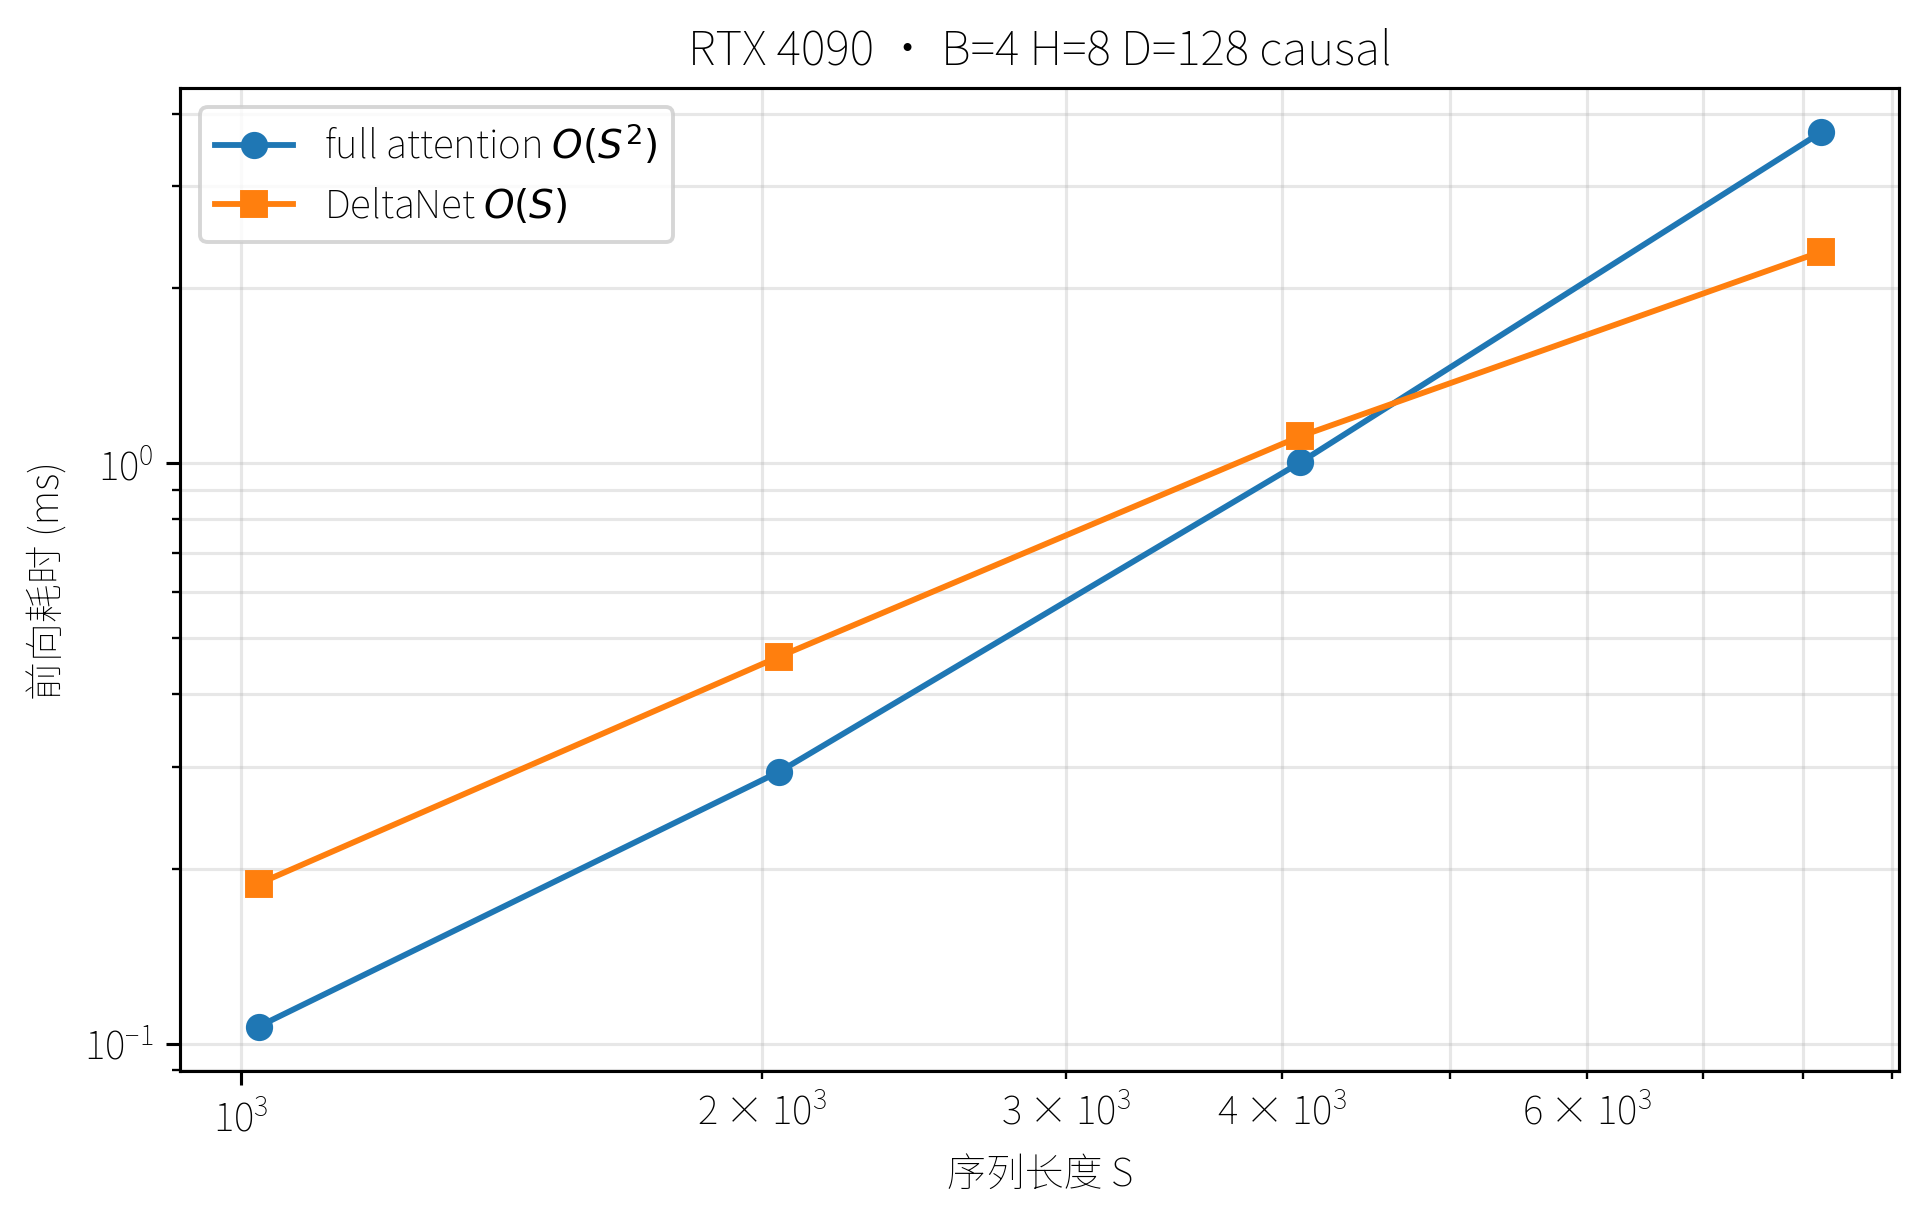

S= 1024  full  0.107ms  DeltaNet  0.189ms (0.57×)
S= 2048  full  0.294ms  DeltaNet  0.464ms (0.63×)
S= 4096  full  1.003ms  DeltaNet  1.112ms (0.90×)
S= 8192  full  3.711ms  DeltaNet  2.312ms (1.61×)


In [8]:
from common import bench_ms
from deltanet_triton import delta_chunk

B, H, D = 4, 8, 128
Ss = [1024, 2048, 4096, 8192]
full, dn_t = [], []
for S in Ss:
    q = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    k = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    v = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    qb, kb, vb = (x.to(torch.bfloat16) for x in (q, k, v))
    beta = torch.rand(B, H, S, device="cuda", dtype=torch.bfloat16)
    full.append(bench_ms(lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True)))
    dn_t.append(bench_ms(lambda: delta_chunk(qb, kb, vb, beta)))

plt.figure(figsize=(7, 4.5))
plt.plot(Ss, full, "o-", label="full attention $O(S^2)$")
plt.plot(Ss, dn_t, "s-", label="DeltaNet $O(S)$")
plt.xlabel("序列长度 S"); plt.ylabel("前向耗时 (ms)"); plt.yscale("log"); plt.xscale("log")
plt.title("RTX 4090 · B=4 H=8 D=128 causal"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
for i, S in enumerate(Ss):
    print(f"S={S:>5}  full {full[i]:6.3f}ms  DeltaNet {dn_t[i]:6.3f}ms ({full[i]/dn_t[i]:.2f}×)")

## 🛠 动手练习

1. **前向替换 = 高效求逆**：把 WY 的 `for i in range(1, C)` 前向替换循环换成 `torch.linalg.inv(I + T)`，验证两者结果一致——
   理解"前向替换"只是利用下三角结构高效地算 $(I+T)^{-1}$。
2. **谱半径爆炸**：去掉 `l2norm=True`，用未归一化的 `k` 跑 recurrent，观察状态如何发散成 nan（此时 $(I-\beta kk^\top)$ 的谱
   半径 > 1）。这解释了为什么 delta-rule 系必须 L2norm。
3. **覆盖强度**：把 $\beta$ 从 1 调到 0.3，重做 §1 的"同 key 覆盖"实验，看读出从"完全覆盖成 $v_b$"变成"$v_a,v_b$ 的混合"。
4. **反向加倍**（§6 延伸）：在手推 backward 里把 `torch.linalg.inv` 换成 §4.1 的前向替换、并实现其反向，验证 $dk$ 不变——
   体会 fla 的 `solve_tril` 为何要单独写一个 bwd kernel。

## 8. 收尾

DeltaNet 给线性注意力装上了"橡皮擦"：

1. **无法覆盖**（§1）：朴素 linear attention 只加不减，同 key 重写只会累加 $v_a+v_b$；
2. **delta rule 几何**（§2）：$(I-\beta k k^\top)$ 沿 $k$ 方向擦除旧值再写新值，"先擦后写"实现覆盖更新、缓解键串扰——
   这是后续 KDA / GDN 全系的共同基础；
3. **WY 表示**（§3）：把块内串行擦除写成 $(I+T)U=\beta V$，一次三角求逆解开，是 chunk 并行的地基；DeltaNet 无门控、
   是最干净的原型（$T_{ij}=\beta_i k_i^\top k_j$）；
4. **逐段精读 + 完整 kernel**（§4–§5）：可读参考实现的每段都对应公式与 Triton 位置，本仓库完整解耦自 fla、与原版一致；
5. **反向传播**（§6）：backward = 块间 **BPTT 反向扫描** + **WY 求逆梯度** $dL=-T^\top dT\,T^\top$ + 块内梯度，手推与 autograd
   逐位一致——这套结构（扫描 + 求逆梯度）对 12-KDA / 13-GDN / 15-SSD 的 chunk_bwd 同样成立。

**下一章** → 12-kda：在这个擦除算子上叠加 per-channel 门控遗忘（KDA = GLA 门控 ⊕ DeltaNet 纠错），再到 13 章把 erase/write
解耦成两个门（GDN/GDN-2）。